## 01 Import Data

### 01-1 Setup Config

In [14]:
from dotenv import load_dotenv
from utils import init_mlflow
import os
import json
load_dotenv()
POSTGRES_URI = os.getenv('POSTGRES_URI')
os.environ["GIT_PYTHON_REFRESH"] = "quiet"

# Set the stock code you want to analyze
STOCK_CODE = 2330

map_dict_path = '/app/data/column_mapping.json'
init_mlflow()
with open(map_dict_path, 'r', encoding='utf-8') as f:
    map_dict = json.load(f)
# '6770', '2337', '2344', '2303', '2408', '2515', '5521', '2542', '1316', '2442', '2485', '6285', '2455', '2412', '4977', '2367', '2313', '3037', '4958', '2327'

In [15]:
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, r2_score
from collections import defaultdict
import math
import mlflow

%matplotlib inline

START_DATE = "2020-01-01"
END_DATE = "2026-03-30"

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
Colour_Palette = ['#01BEFE', '#FF7D00', '#FFDD00', '#FF006D', '#ADFF02', '#8F00FF']
sns.set_palette(sns.color_palette(Colour_Palette))
tqdm.pandas()
mlflow.set_experiment("LSTM_Test")
mlflow.config.enable_system_metrics_logging()
mlflow.config.set_system_metrics_sampling_interval(1)

### 01-2 Load Data

In [16]:
def get_stock_data(stock_code, start_date: str, end_date: str, return_all=False):
    # Fetch data from PostgreSQL database
    table_name = f'daily_info_{stock_code}'
    query = f"""
    SELECT *
    FROM {table_name}
    WHERE stock_code_id = '{stock_code}'
      AND date BETWEEN '{start_date}' AND '{end_date}'
    ORDER BY date ASC;
    """
    df = pd.read_sql(query, POSTGRES_URI)

    # Rename columns using the mapping dictionary
    df.rename(columns=map_dict, inplace=True)
    return df

df = get_stock_data(STOCK_CODE, START_DATE, END_DATE)
df.head()

,date,capacity,turnover,high,low,close,change,transaction_volume,stock_code_id,open
0,2020-01-02 01:00:00,33282120.0,1.122417e+10,339.0,332.5,339.0,8.0,17160,2330,332.5
1,2020-01-03 01:00:00,42023268.0,1.429565e+10,345.0,335.5,339.5,0.5,20545,2330,344.0
2,2020-01-06 01:00:00,45677057.0,1.521053e+10,334.5,332.0,332.0,-7.5,22944,2330,333.0
3,2020-01-07 01:00:00,51746181.0,1.705328e+10,333.0,326.5,329.5,-2.5,22362,2330,332.5
4,2020-01-08 01:00:00,37913748.0,1.248441e+10,333.0,325.0,329.5,0.0,18228,2330,325.0


In [17]:
# Fill null values in 'change' using the values from 'change_new' (today's close - yesterday's close)
df['change_new'] = df['close']-df['close'].shift(1)
df['change'] = df['change'].fillna(df['change_new'])
df = df.drop(columns=['change_new'])
df.isnull().sum()

date                  0
capacity              0
turnover              0
high                  0
low                   0
close                 0
change                0
transaction_volume    0
stock_code_id         0
open                  0
dtype: int64

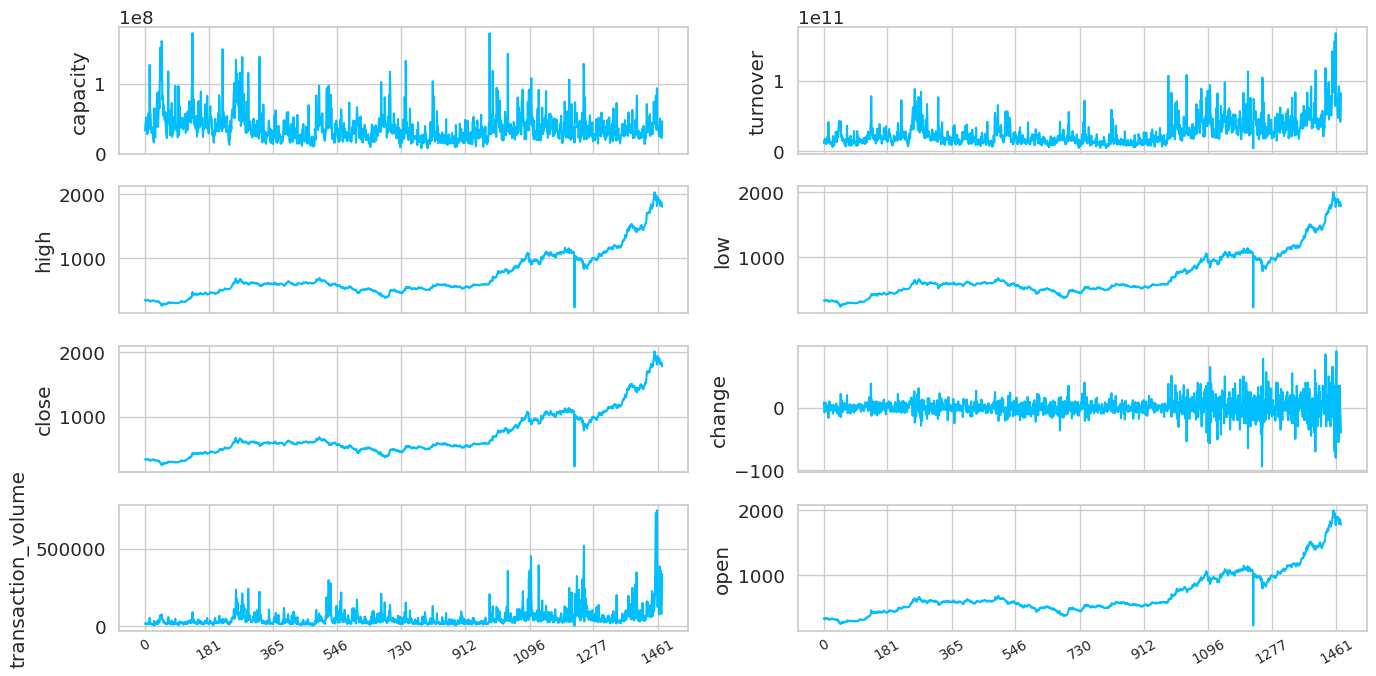

In [18]:
def data_plot(df):
    # Plot line charts
    df_plot = df.drop(columns=['stock_code_id', 'date'])

    ncols = 2
    nrows = int(round(df_plot.shape[1] / ncols, 0))

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, figsize=(14, 7))
    for i, ax in enumerate(fig.axes):
        sns.lineplot(data=df_plot.iloc[:, i], ax=ax)
        ax.tick_params(axis="x", rotation=30, labelsize=10, length=0)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.tight_layout()
    plt.show()

data_plot(df)

### 01-3 Feature Engineering

In [19]:
# Train test split
train_ratio = 0.8
validation_ratio = 0.1
test_ratio = 1 - train_ratio - validation_ratio
predict_col = 'close'

# Try using only 'close' as the feature for prediction
df_X_train, df_X_test, df_y_train, df_y_test = train_test_split(
    # df.drop(columns=[predict_col]),
    df[[predict_col]], 
    df[predict_col], 
    test_size=1-train_ratio, 
    shuffle=False
)
df_X_val, df_X_test, df_y_val, df_y_test = train_test_split(
    df_X_test, 
    df_y_test, 
    test_size=test_ratio/(test_ratio + validation_ratio), 
    shuffle=False
)
print(f"Train set: {df_X_train.shape[0]} samples")
print(f"Validation set: {df_X_val.shape[0]} samples")
print(f"Test set: {df_X_test.shape[0]} samples")

Train set: 1180 samples
Validation set: 147 samples
Test set: 148 samples


In [20]:
# Reshape and scale data
scaler = MinMaxScaler(feature_range=(0, 1))
df_X_train_scaled = scaler.fit_transform(
    # df_X_train.drop(columns=['date', 'stock_code_id'])
    df_X_train
)
df_X_val_scaled = scaler.transform(
    # df_X_val.drop(columns=['date', 'stock_code_id'])
    df_X_val
)
df_X_test_scaled = scaler.transform(
    # df_X_test.drop(columns=['date', 'stock_code_id'])
    df_X_test
)
df_y_train_scaled = scaler.fit_transform(df_y_train.values.reshape(-1, 1))
df_y_val_scaled = scaler.transform(df_y_val.values.reshape(-1, 1))
df_y_test_scaled = scaler.transform(df_y_test.values.reshape(-1, 1))
print(df_X_train_scaled[:5], df_y_train_scaled[:5])

[[0.10807601]
 [0.10866983]
 [0.09976247]
 [0.09679335]
 [0.09679335]] [[0.10807601]
 [0.10866983]
 [0.09976247]
 [0.09679335]
 [0.09679335]]


## 02 Model Training

### 02-1 Create Sequences and Labels for training and testing

In [21]:
# Create sequences and labels for training data
sequence_length = 14  # Number of time steps to look back
X_train, y_train = [], []
for i in range(len(df_X_train_scaled) - sequence_length):
    X_train.append(df_X_train_scaled[i:i + sequence_length])
    y_train.append(df_y_train_scaled[i + sequence_length])  # Predicting the value right after the sequence
X_train, y_train = np.array(X_train), np.array(y_train)

# Convert data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_val, y_val = [], []
for i in range(len(df_X_val_scaled) - sequence_length):
    X_val.append(df_X_val_scaled[i:i + sequence_length])
    y_val.append(df_y_val_scaled[i + sequence_length])  # Predicting the value right after the sequence
X_val, y_val = np.array(X_val), np.array(y_val)

# Convert data to PyTorch tensors
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

# Create sequences and labels for testing data
X_test, y_test = [], []
for i in range(len(df_X_test_scaled) - sequence_length):
    X_test.append(df_X_test_scaled[i:i + sequence_length])
    y_test.append(df_y_test_scaled[i + sequence_length])  # Predicting the value right after the sequence
X_test, y_test = np.array(X_test), np.array(y_test)

# Convert data to PyTorch tensors
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: torch.Size([1166, 14, 1])
y_train shape: torch.Size([1166, 1])
X_val shape: torch.Size([133, 14, 1])
y_val shape: torch.Size([133, 1])
X_test shape: torch.Size([134, 14, 1])
y_test shape: torch.Size([134, 1])


In [22]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :])  # Use the output of the last time step
        return out
    
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")  

Using device: cuda


In [23]:
# Setup model parameters
params = {
    'input_size': X_train.shape[2],
    'hidden_size': 32,
    'num_layers': 3,
    'output_size': 1,
    'dropout': 0.3,
}

model = LSTMModel(params['input_size'], params['hidden_size'], params['num_layers'], params['output_size'], params['dropout']).to(device)
loss_fn = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters(), lr=0.001)

batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # Shuffle training data for better generalization
val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_epochs = 100
train_hist = []
val_hist = []

with mlflow.start_run(nested=True) as run:
    # Log training parameters
    mlflow.log_params(params)
    for epoch in range(num_epochs):
        total_loss = 0
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch,y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_hist.append(avg_loss)

        model.eval()
        with torch.no_grad():
            total_val_loss = 0
            for X_val_batch, y_val_batch in val_loader:
                X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
                val_predictions = model(X_val_batch)
                val_loss = loss_fn(val_predictions, y_val_batch)
                total_val_loss += val_loss.item()

            avg_val_loss = total_val_loss / len(val_loader)
            val_hist.append(avg_val_loss)
            # Log epoch metrics
        mlflow.log_metrics(
            {
                "train_loss": avg_loss,
                "val_loss": avg_val_loss,
            },
            step=epoch,
        )

        if (epoch + 1)%10 == 0:
            print(f"Epoch[{epoch + 1}/{num_epochs}] - Train Loss: {avg_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

    # Log checkpoint at the end of each epoch
    mlflow.pytorch.log_model(model, name=f"checkpoint_{epoch}")

2026/04/10 03:51:47 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/10 03:51:47 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Epoch[10/100] - Train Loss: 0.0018 - Val Loss: 0.0109
Epoch[20/100] - Train Loss: 0.0013 - Val Loss: 0.0096
Epoch[30/100] - Train Loss: 0.0011 - Val Loss: 0.0093
Epoch[40/100] - Train Loss: 0.0009 - Val Loss: 0.0096
Epoch[50/100] - Train Loss: 0.0009 - Val Loss: 0.0092
Epoch[60/100] - Train Loss: 0.0008 - Val Loss: 0.0116
Epoch[70/100] - Train Loss: 0.0007 - Val Loss: 0.0086
Epoch[80/100] - Train Loss: 0.0007 - Val Loss: 0.0089
Epoch[90/100] - Train Loss: 0.0006 - Val Loss: 0.0089
Epoch[100/100] - Train Loss: 0.0006 - Val Loss: 0.0089


2026/04/10 03:52:12 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/10 03:52:12 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/10 03:52:19 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it

🏃 View run able-fish-787 at: http://172.18.0.3:5000/#/experiments/2/runs/0e108e60ff0048aeb412454857c9ac03
🧪 View experiment at: http://172.18.0.3:5000/#/experiments/2


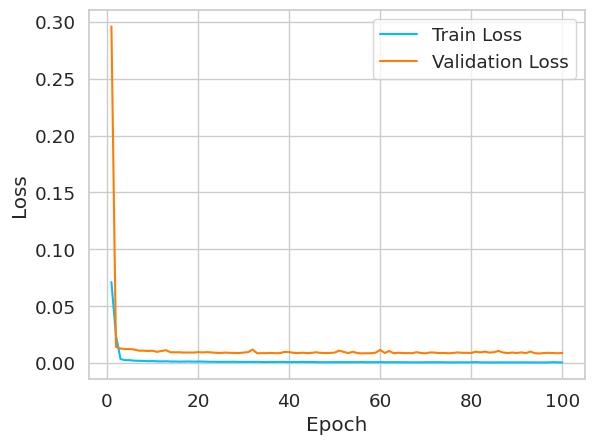

In [24]:
x = np.linspace(1, num_epochs, num_epochs)
plt.plot(x, train_hist, scalex=True, label='Train Loss')
plt.plot(x, val_hist, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 03 Forecasting and evaluate

In [25]:
# num_forecast_steps = 14
# sequence_to_plot = X_test.squeeze().cpu().numpy()
# historical_data = sequence_to_plot[-1]

# forecasted_values = []
# with torch.no_grad():
#     for _ in range(num_forecast_steps):
#         historical_data_tensor = torch.as_tensor(historical_data).view(1, -1, 1).float().to(device)
#         predicted_value = model(historical_data_tensor).cpu().numpy()[0, 0]
#         forecasted_values.append(predicted_value)
#         historical_data = np.roll(historical_data, shift=-1)
#         historical_data[-1] = predicted_value

# last_date = X_test.index[-1]
# future_dates = pd.date_range(start=last_date + pd.DateOffset(1), periods=30)

# plt.rcParams['figure.figsize'] = [14, 4]
# plt.plot(X_test.index[-100:], X_test.Open[-100:], label="test_data", color="b")
# plt.plot(X_test.index[-30:], X_test.Open[-30:], label='actual values', color='green')
# plt.plot(X_test.index[-1:].append(future_dates), np.concatenate([X_test.Open[-1:], scaler.inverse_transform(np.array(forecasted_values).reshape(-1, 1)).flatten()]), label='forecasted values', color='red')

# plt.xlabel('Time Step')
# plt.ylabel('Value')
# plt.legend()
# plt.title('Time Series Forecasting')
# plt.grid(True)
# plt.show()

# # Evaluate the model and calculate RMSE and R² score
# model.eval()
# with torch.no_grad():
#     test_predictions = []
#     for batch_X_test in X_test:
#         batch_X_test = batch_X_test.to(device).unsqueeze(0)  # Add batch dimension
#         test_predictions.append(model(batch_X_test).cpu().numpy().flatten()[0])

# test_predictions = np.array(test_predictions)

# # Calculate RMSE and R² score
# rmse = np.sqrt(mean_squared_error(y_test.cpu().numpy(), test_predictions))
# r2 = r2_score(y_test.cpu().numpy(), test_predictions)

# print(f'RMSE: {rmse:.4f}')
# print(f'R² Score: {r2:.4f}')

RMSE: 83.4259
R² Score: 0.4261


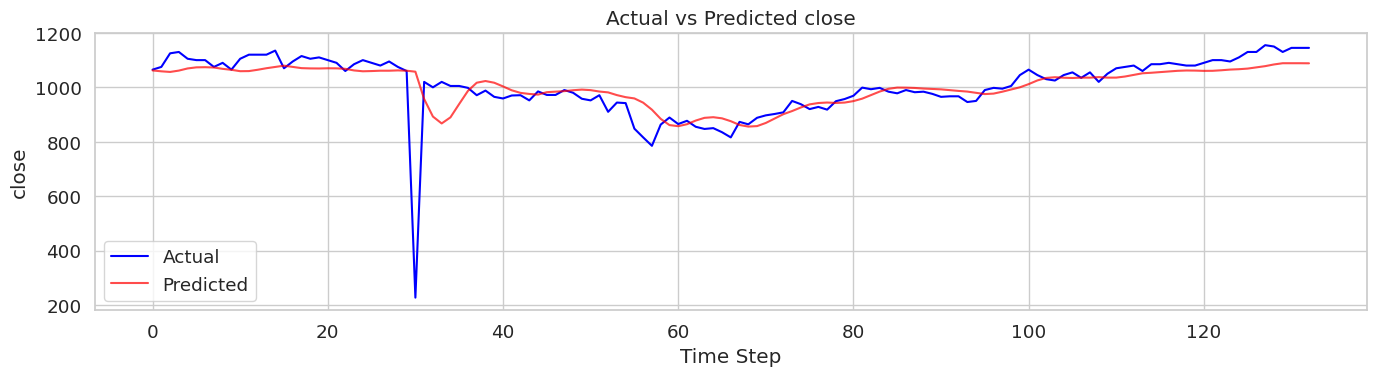

In [26]:
# Evaluate the model and calculate RMSE and R² score
model.eval()
with torch.no_grad():
    val_predictions = []
    for batch_X_val in X_val:
        batch_X_val = batch_X_val.to(device).unsqueeze(0)  # (1, seq_len, input_size)
        val_predictions.append(model(batch_X_val).cpu().numpy().flatten()[0])

val_predictions = np.array(val_predictions)
y_val_np = y_val.cpu().numpy().flatten()

# Inverse transform to original scale
y_scaler = MinMaxScaler()
y_scaler.fit(df_y_train.values.reshape(-1, 1))
y_val_inv = y_scaler.inverse_transform(y_val_np.reshape(-1, 1)).flatten()
val_pred_inv = y_scaler.inverse_transform(val_predictions.reshape(-1, 1)).flatten()

# Calculate RMSE and R² score
rmse = np.sqrt(mean_squared_error(y_val_inv, val_pred_inv))
r2 = r2_score(y_val_inv, val_pred_inv)
print(f'RMSE: {rmse:.4f}')
print(f'R² Score: {r2:.4f}')

# Plot actual vs predicted
plt.rcParams['figure.figsize'] = [14, 4]
plt.plot(y_val_inv, label='Actual', color='blue')
plt.plot(val_pred_inv, label='Predicted', color='red', alpha=0.7)
plt.xlabel('Time Step')
plt.ylabel(predict_col)
plt.legend()
plt.title(f'Actual vs Predicted {predict_col}')
plt.grid(True)
plt.tight_layout()
plt.show()

Note: 會這麼低是因為目前將 LSTM 拆成 Train / Val / Test，而 Test 由於天數已經過太久導致模型預測偏差太大!因此應該嘗試將 LSTM 拆成 Train / Test 就好

## END